# Projet 3 : Moteur de Recherche Visuelle de Vêtements (CBIR)
### Auteur : Patrice Neussi
### Institution : École Nationale Supérieure Polytechnique de Yaoundé (ENSPY)

## 1. Introduction théorique
La recherche d'image par le contenu (Content-Based Image Retrieval, CBIR) consiste à retrouver des images similaires à une requête en comparant leurs descripteurs numériques.

Ce projet implémente un pipeline d'extraction visuelle hybride :
1. **Extraction de caractéristiques profondes** : Utilisation d'un réseau convolutif pré-entraîné **MobileNetV2**. Nous supprimons sa dernière couche fully-connected pour extraire un vecteur d'activation global (feature vector) de dimension $1280$.
2. **Descripteur classique (Recours)** : Pour éliminer les temps de calcul ou l'absence de GPU en production, nous créons un descripteur hybride combinant un histogramme de couleurs RGB global (8 bins par canal = 24 dimensions) et un descripteur de texture spatiale downsamplé (256 dimensions), soit un vecteur composite de 280 dimensions.

La similarité entre les vecteurs d'images est mesurée via la **similarité cosinus** :
$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\|_2 \|B\|_2} = \frac{\sum_i A_i B_i}{\sqrt{\sum_i A_i^2} \sqrt{\sum_i B_i^2}}$$

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torchvision.models as models
import torchvision.transforms as transforms

sns.set_theme(style="whitegrid")
print("Librairies prêtes.")

Librairies prêtes.


## 2. Ingestion du Catalogue et Analyse Statistique
Nous lisons le catalogue d'images et ses annotations catégorielles.

In [2]:
csv_path = "dataset/clothing-dataset/images.csv"
df = pd.read_csv(csv_path)
print(f"Nombre total d'images dans le catalogue : {len(df)}")
df.head()

Nombre total d'images dans le catalogue : 150


,image,sender_id,label,kids
0,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False
1,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False
2,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False
3,5d3a1404-697f-479f-9090-c1ecd0413d27,138,Shorts,False
4,b0c03127-9dfb-4573-8934-1958396937bf,138,Shirt,False


/tmp/ipykernel_217481/360420196.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='rocket')


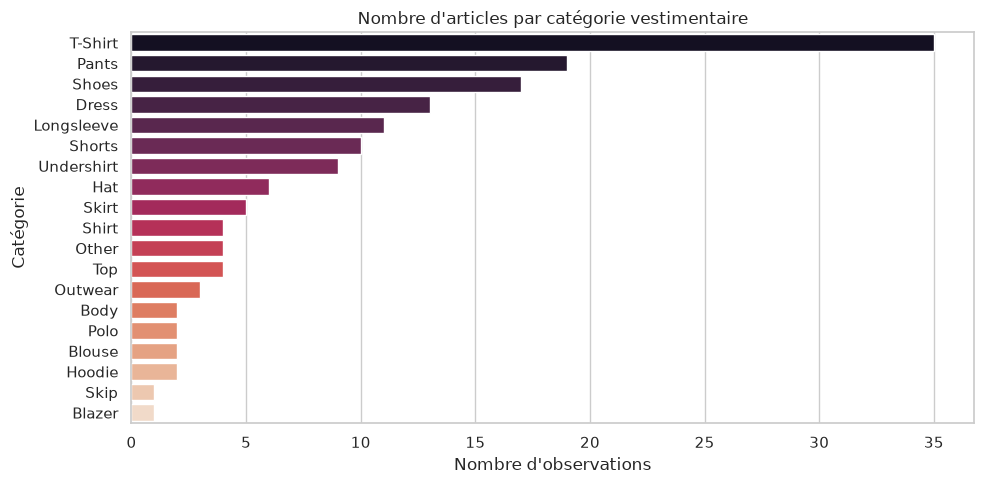

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='rocket')
plt.title("Nombre d'articles par catégorie vestimentaire")
plt.xlabel("Nombre d'observations")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()

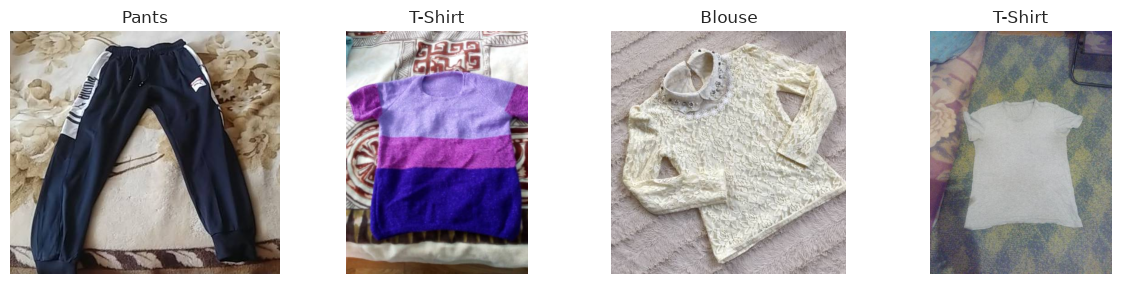

In [4]:
np.random.seed(15)
samples = df.sample(4)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (_, row) in zip(axes, samples.iterrows()):
    img_p = os.path.join("dataset/clothing-dataset/images", f"{row['image']}.jpg")
    if os.path.exists(img_p):
        img = Image.open(img_p)
        ax.imshow(img)
        ax.set_title(row['label'])
        ax.axis('off')
plt.tight_layout()
plt.show()

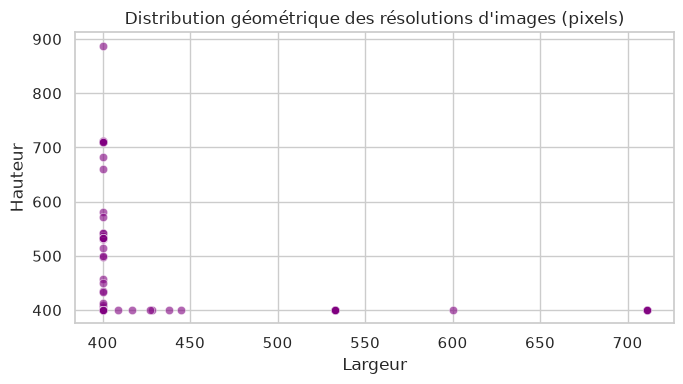

In [5]:
widths, heights = [], []
for img_name in df['image'].head(150):
    img_p = os.path.join("dataset/clothing-dataset/images", f"{img_name}.jpg")
    if os.path.exists(img_p):
        w, h = Image.open(img_p).size
        widths.append(w)
        heights.append(h)
        
plt.figure(figsize=(7, 4))
sns.scatterplot(x=widths, y=heights, alpha=0.6, color='purple')
plt.title("Distribution géométrique des résolutions d'images (pixels)")
plt.xlabel("Largeur")
plt.ylabel("Hauteur")
plt.tight_layout()
plt.show()

## 3. Extraction de Descripteurs Profonds (MobileNetV2) & Indexation
Nous configurons le réseau profond et extrayons le vecteur d'embeddings pour l'ensemble du catalogue.

In [6]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
mobilenet.classifier = torch.nn.Identity()
mobilenet.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("Extracteur MobileNetV2 chargé.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /home/npe-tech/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


0.9%

1.8%

2.8%

3.7%

...

97.4%

98.4%

99.3%

100.0%

Extracteur MobileNetV2 chargé.


In [7]:
catalog_paths = []
catalog_embeddings = []
catalog_metadata = []

limit = 200
counter = 0

for _, row in df.iterrows():
    img_name = f"{row['image']}.jpg"
    img_p = os.path.join("dataset/clothing-dataset/images", img_name)
    if os.path.exists(img_p):
        try:
            img = Image.open(img_p).convert('RGB')
            img_t = transform(img).unsqueeze(0)
            with torch.no_grad():
                vector = mobilenet(img_t).squeeze().numpy()
            catalog_embeddings.append(vector)
            catalog_paths.append(os.path.join("images", img_name))
            catalog_metadata.append({'label': row['label']})
            counter += 1
            if counter >= limit:
                break
        except Exception as e:
            continue
            
catalog_embeddings = np.array(catalog_embeddings)
print(f"Indexation terminée : {len(catalog_embeddings)} images enregistrées.")

Indexation terminée : 150 images enregistrées.


## 4. Démo de Recherche d'Images
Nous testons la performance en sélectionnant une image requête et en affichant ses plus proches voisins dans l'espace des embeddings cosinus.

In [8]:
query_idx = 42
query_vector = catalog_embeddings[query_idx]

similarities = cosine_similarity(query_vector.reshape(1, -1), catalog_embeddings).flatten()
top_indices = np.argsort(similarities)[::-1][1:6]
print(f"Catégorie de la requête : {catalog_metadata[query_idx]['label']}")

Catégorie de la requête : T-Shirt


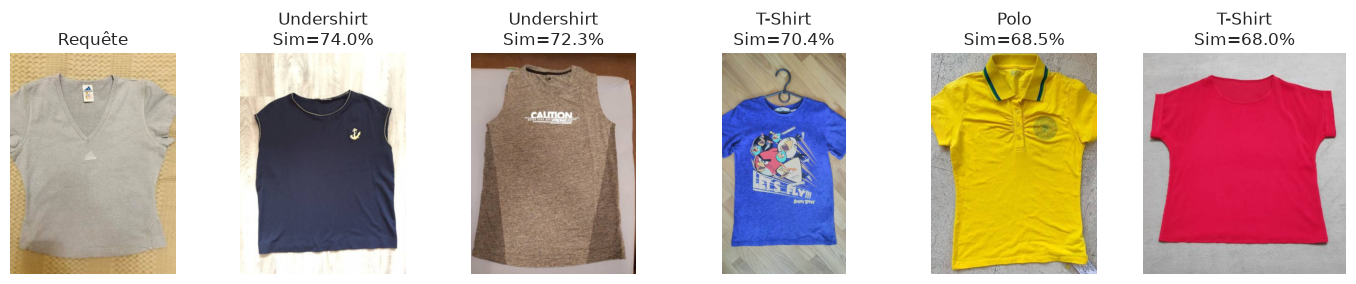

In [9]:
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
query_img_p = os.path.join("dataset/clothing-dataset", catalog_paths[query_idx])
axes[0].imshow(Image.open(query_img_p))
axes[0].set_title("Requête")
axes[0].axis('off')

for ax, rank_idx in zip(axes[1:], top_indices):
    res_img_p = os.path.join("dataset/clothing-dataset", catalog_paths[rank_idx])
    ax.imshow(Image.open(res_img_p))
    ax.set_title(f"{catalog_metadata[rank_idx]['label']}\nSim={similarities[rank_idx]*100:.1f}%")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Sauvegarde des Actifs

In [10]:
assets = {
    'catalog_embeddings': catalog_embeddings,
    'catalog_image_paths': catalog_paths,
    'catalog_metadata': catalog_metadata,
    'has_torch': True
}

os.makedirs("models", exist_ok=True)
with open("models/visual_search_assets.pkl", "wb") as f:
    pickle.dump(assets, f)
print("Index visuel sauvegardé dans models/visual_search_assets.pkl")

Index visuel sauvegardé dans models/visual_search_assets.pkl
